# 6. Extraindo _Features_ de LLMs


Este notebook tem como objetivo analisar o desempenho de diferentes modelos de linguagem (LLMs) na resolução de questões do ENEM. São extraídas respostas automáticas dos modelos, comparadas com o gabarito oficial e também com amostras reais de respostas de alunos. O fluxo inclui preparação dos dados, configuração dos prompts, consulta aos modelos, avaliação dos acertos e análise comparativa dos resultados.

In [ ]:
# Importando as bibliotecas para lidar com LLMs
import matplotlib.pyplot as plt
import pandas as pd
import random
import ollama
import re
from openai import OpenAI

In [4]:
# Caminho dos dados
input_path = "../data/final/enem_data_embeddings.pkl"
output_path = "../data/final/complete_enem_data.pkl"

In [5]:
# Leitura dos dados tokenizados
df = pd.read_pickle(input_path)
df

,numero_questao,enunciado,alternativas,gabarito,questao,pc_amostra_acertos,ano,gabarito_texto,distratores,enunciado_tokens,...,distratores_embbedings_word2vec_100,similaridade_enunciado_gabarito_100,similaridade_enunciado_distratores_100,similaridade_gabarito_distratores_100,enunciado_embbedings_word2vec_50,gabarito_embbedings_word2vec_50,distratores_embbedings_word2vec_50,similaridade_enunciado_gabarito_50,similaridade_enunciado_distratores_50,similaridade_gabarito_distratores_50
0,1,A atmosfera terrestre é composta pelos gases n...,A: reduzir o calor irradiado pela Terra median...,C,1,0.93,2009,"reduzir o desmatamento, mantendo-se, assim, o ...",reduzir o calor irradiado pela Terra mediante ...,atmosfera terrestre composta gases nitrogênio ...,...,"[0.06891932, -0.056490835, 0.032688133, -0.018...",0.694265,0.860440,0.817126,"[0.08906648, 0.18746194, 0.09568582, -0.018923...","[0.177859, 0.14451149, -0.033945624, 0.12138, ...","[0.16039853, 0.15997498, 0.05087997, 0.0837478...",0.728683,0.867395,0.862642
1,2,Analise a figura. Supondo que seja necessário ...,A: Concentração média de álcool no sangue ao l...,D,2,0.40,2009,Estimativa de tempo necessário para metaboliza...,Concentração média de álcool no sangue ao long...,analise figura supondo necessário dar título f...,...,"[0.13126856, -0.0030684425, 0.13112548, 0.0888...",0.356290,0.327731,0.745641,"[0.0029705844, -0.0016135853, 0.007862832, 0.0...","[0.09892542, 0.057256144, 0.0030154246, 0.0359...","[0.07989774, 0.17586634, 0.0062733707, 0.03847...",0.428181,0.453869,0.808209
2,3,Estima-se que haja atualmente no mundo 40 milh...,"A: induzir a imunidade, para proteger o organi...",A,3,0.40,2009,"induzir a imunidade, para proteger o organismo...",ser capaz de alterar o genoma do organismo por...,estima atualmente mundo milhões pessoas infect...,...,"[0.074030176, 0.0145144975, 0.075817436, -0.10...",0.614781,0.708427,0.747481,"[0.037406296, 0.11757571, 0.023855807, 0.08883...","[0.10099166, 0.1493785, 0.084694505, 0.0487238...","[0.030623527, 0.19797918, 0.10676692, 0.043068...",0.672166,0.781778,0.761080
3,4,"Em um experimento, preparou-se um conjunto de ...",A: os genótipos e os fenótipos idênticos.; B: ...,B,4,0.61,2009,os genótipos idênticos e os fenótipos diferentes.,os genótipos e os fenótipos idênticos.; difere...,experimento preparou conjunto plantas técnica ...,...,"[-0.0139715355, 0.07850413, 0.0008902701, 0.06...",0.451360,0.594306,0.854987,"[-0.029311944, 0.10550189, 0.05036179, -0.0101...","[0.017343253, 0.35315275, 0.20922275, -0.09720...","[-0.010322735, 0.35458034, 0.16574, 0.0417216,...",0.554718,0.669521,0.872565
4,5,"Na linha de uma tradição antiga, o astrônomo g...",A: Ptolomeu apresentou as ideias mais valiosas...,E,5,0.60,2009,"Kepler apresentou uma teoria científica que, g...","Ptolomeu apresentou as ideias mais valiosas, p...",linha tradição antiga astrônomo grego ptolomeu...,...,"[-0.026497144, -0.0024524825, 0.008412318, -0....",0.431371,0.765725,0.577122,"[0.04814419, 0.08036936, 0.0690699, -0.0082249...","[-0.1161132, 0.0615291, -0.0451972, -0.0884399...","[0.0076814005, 0.03361294, -0.0035526846, -0.0...",0.460525,0.812388,0.539009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,130,O número de abelhas encontra-se em declínio em...,A: reduz sua predação.; B: reduz o uso de pest...,D,130,0.35,2023,aumenta a oferta de alimento.,reduz sua predação.; reduz o uso de pesticidas...,número abelhas encontra declínio várias regiõe...,...,"[0.008991817, -0.0042170887, 0.024945997, 0.06...",0.555215,0.565581,0.755006,"[0.009540408, 0.12904784, 0.02322217, -0.01718...","[0.23240267, 0.012514338, -0.07278166, 0.07023...","[-0.016479364, 0.10528354, -0.096228, -0.04221...",0.581634,0.570017,0.828974
601,131,Os mais antigos cozinhavam o feijão na panela ...,A: tratar a diarreia.; B: prevenir a anemia.; ...,B,131,0.77,2023,prevenir a anemia.,tratar a diarreia.; evitar as verminoses.; rem...,antigos cozinhavam feijão pan

---

## 6.1. Configuração do Prompt


In [5]:
# Definindo prompt para o modelo
prompt = """Responda à seguinte questão:

    Enunciado:
    {enunciado}

    Alternativas:
    {alternativas}

    Qual a alternativa correta? Responda apenas com a letra (A, B, C, D ou E). Não responda mais nada além da letra."""

In [6]:
# Função para remover conteúdo entre <think> e </think> (DeepSeek)
def remove_think_tags(text):
    return re.sub(r"<THINK>.*?</THINK>", "", text, flags=re.DOTALL)

In [ ]:
# Função para perguntar ao modelo
def ask_llm(enunciado: str, alternativas: str, model_name: str):

    # Construindo mensagem
    message = [
        {
            "role": "user",
            "content": prompt.format(enunciado=enunciado, alternativas=alternativas),
        }
    ]

    try:
        # Enviando prompt para o modelo
        result = ollama.chat(model=model_name, messages=message)
        resposta = result["message"]["content"].strip().upper()
        resposta_limpa = remove_think_tags(resposta)

        # Capturando a letra da resposta
        match = re.search(r"\b[A-E]\b", resposta_limpa.upper())
        resposta_letra = match.group(0) if match else "x"

        return resposta_letra

    except Exception as e:
        print(f"Erro ao consultar modelo: {e}")
        return "?"

---

## 6.2. Llamma 3.2


In [ ]:
# LLM Utilizado: Llamma 3.2 (localmente)
# https://ollama.com/library/llama3.2
model_name = "llama3.2:latest"

In [ ]:
# Registrando resposta do modelo (A, B, C, D ou E)
df["resposta_llamma"] = df[["enunciado", "alternativas"]].apply(
    lambda row: ask_llm(row["enunciado"], row["alternativas"], model_name), axis=1
)

In [ ]:
# Registrando acerto do modelo (True ou False)
df["acerto_llamma"] = df[["gabarito", "resposta_llamma"]].apply(
    lambda row: row["gabarito"] == row["resposta_llamma"], axis=1
)

---

## 6.3. DeepSeek-R1


In [12]:
# LLM Utilizado: DeepSeek-R1-Distill-Qwen-7B (localmente)
# https://ollama.com/library/deepseek-r1
model_name = "deepseek-r1:7b"

In [ ]:
# Registrando resposta do modelo (A, B, C, D ou E)
df["resposta_deepseek"] = df[["enunciado", "alternativas"]].apply(
    lambda row: ask_llm(row["enunciado"], row["alternativas"], model_name), axis=1
)

In [ ]:
# Registrando acerto do modelo (True ou False)
df["acerto_deepseek"] = df[["gabarito", "resposta_deepseek"]].apply(
    lambda row: row["gabarito"] == row["resposta_deepseek"], axis=1
)

### 6.3.1. OpenRouter para DeepSeek-R1


In [ ]:
# Verificando quantas respostas DeepSeek falharam
len(df[df["resposta_deepseek"] == "?"])

228

In [ ]:
# Verificando quantas respostas foram obtidas
df[df["resposta_deepseek"] != "?"].shape[0]

377

In [ ]:
API_KEY = "sua_chave_de_api_openrouter"

# Alternativa: Usando OpenRouter para DeepSeek-R1
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=API_KEY,
)


def ask_openrouter(enunciado: str, alternativas: str):
    prompt = """Responda à seguinte questão:

  Enunciado:
  {enunciado}

  Alternativas:
  {alternativas}

  Qual a alternativa correta? Responda apenas com a letra (A, B, C, D ou E). Não responda mais nada além da letra."""

    # Enviando prompt para o modelo
    completion = client.chat.completions.create(
        extra_body={},
        model="deepseek/deepseek-r1:free",
        messages=[
            {
                "role": "user",
                "content": prompt.format(
                    enunciado=enunciado, alternativas=alternativas
                ),
            }
        ],
    )
    resposta = completion.choices[0].message.content.strip().upper()
    resposta_limpa = remove_think_tags(resposta)

    # Capturando a letra da resposta
    match = re.search(r"\b[A-E]\b", resposta_limpa.upper())
    resposta_letra = match.group(0) if match else "?"
    return resposta_letra

In [ ]:
# Registrando resposta do modelo (A, B, C, D ou E)
for index, row in df.loc[df["resposta_deepseek"] == "?"].iterrows():
    try:
        df.at[index, "resposta_deepseek"] = ask_openrouter(
            row["enunciado"], row["alternativas"]
        )
    except Exception as e:
        if "429" in str(e):
            print(f"Rate limit exceeded at index {index}: {e}")
            break
        else:
            print(f"Error at index {index}: {e}")
            break

In [ ]:
len(df.loc[df["resposta_deepseek"] == "?"])

0

In [ ]:
# Registrando acerto do modelo (True ou False)
df["acerto_deepseek"] = df[["gabarito", "resposta_deepseek"]].apply(
    lambda row: row["gabarito"] == row["resposta_deepseek"], axis=1
)

---
## 6.4. Comparando Resultados

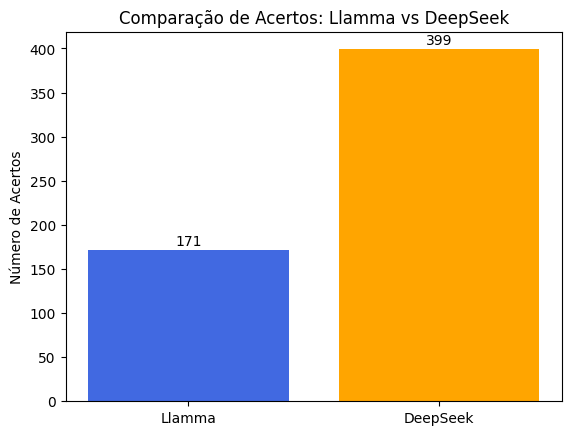

In [13]:
# Contando acertos de cada modelo
acertos = {
    "Llamma": df["acerto_llamma"].sum(),
    "DeepSeek": df["acerto_deepseek"].sum()
}
for i, (model, count) in enumerate(acertos.items()):
    plt.text(i, count + 2, str(count), ha='center', va='bottom', fontsize=10)

# Plotando gráfico de barras
plt.bar(acertos.keys(), acertos.values(), color=["royalblue", "orange"])
plt.ylabel("Número de Acertos")
plt.title("Comparação de Acertos: Llamma vs DeepSeek")
plt.show()

---

## 6.5. Salvando Resultados


In [ ]:
# Salvar resultado
df.to_pickle(output_path)

In [12]:
df = pd.read_pickle(output_path)
df.head()

,numero_questao,enunciado,alternativas,gabarito,questao,pc_amostra_acertos,ano,gabarito_texto,distratores,enunciado_tokens,...,enunciado_embbedings_word2vec_50,gabarito_embbedings_word2vec_50,distratores_embbedings_word2vec_50,similaridade_enunciado_gabarito_50,similaridade_enunciado_distratores_50,similaridade_gabarito_distratores_50,resposta_deepseek,acerto_deepseek,resposta_llamma,acerto_llamma
0,1,A atmosfera terrestre é composta pelos gases n...,A: reduzir o calor irradiado pela Terra median...,C,1,0.93,2009,"reduzir o desmatamento, mantendo-se, assim, o ...",reduzir o calor irradiado pela Terra mediante ...,atmosfera terrestre composta gases nitrogênio ...,...,"[0.08906648, 0.18746194, 0.09568582, -0.018923...","[0.177859, 0.14451149, -0.033945624, 0.12138, ...","[0.16039853, 0.15997498, 0.05087997, 0.0837478...",0.728683,0.867395,0.862642,C,True,C,True
1,2,Analise a figura. Supondo que seja necessário ...,A: Concentração média de álcool no sangue ao l...,D,2,0.40,2009,Estimativa de tempo necessário para metaboliza...,Concentração média de álcool no sangue ao long...,analise figura supondo necessário dar título f...,...,"[0.0029705844, -0.0016135853, 0.007862832, 0.0...","[0.09892542, 0.057256144, 0.0030154246, 0.0359...","[0.07989774, 0.17586634, 0.0062733707, 0.03847...",0.428181,0.453869,0.808209,A,False,C,False
2,3,Estima-se que haja atualmente no mundo 40 milh...,"A: induzir a imunidade, para proteger o organi...",A,3,0.40,2009,"induzir a imunidade, para proteger o organismo...",ser capaz de alterar o genoma do organismo por...,estima atualmente mundo milhões pessoas infect...,...,"[0.037406296, 0.11757571, 0.023855807, 0.08883...","[0.10099166, 0.1493785, 0.084694505, 0.0487238...","[0.030623527, 0.19797918, 0.10676692, 0.043068...",0.672166,0.781778,0.761080,C,False,A,True
3,4,"Em um experimento, preparou-se um conjunto de ...",A: os genótipos e os fenótipos idênticos.; B: ...,B,4,0.61,2009,os genótipos idênticos e os fenótipos diferentes.,os genótipos e os fenótipos idênticos.; difere...,experimento preparou conjunto plantas técnica ...,...,"[-0.029311944, 0.10550189, 0.05036179, -0.0101...","[0.017343253, 0.35315275, 0.20922275, -0.09720...","[-0.010322735, 0.35458034, 0.16574, 0.0417216,...",0.554718,0.669521,0.872565,B,True,B,True
4,5,"Na linha de uma tradição antiga, o astrônomo g...",A: Ptolomeu apresentou as ideias mais valiosas...,E,5,0.60,2009,"Kepler apresentou uma teoria científica que, g...","Ptolomeu apresentou as ideias mais valiosas, p...",linha tradição antiga astrônomo grego ptolomeu...,...,"[0.04814419, 0.08036936, 0.0690699, -0.0082249...","[-0.1161132, 0.0615291, -0.0451972, -0.0884399...","[0.0076814005, 0.03361294, -0.0035526846, -0.0...",0.460525,0.812388,0.539009,E,True,A,False


---